In [2]:
#importing the dataset
import pandas as pd

In [3]:
df = pd.read_excel ("Dataset for Data Analytics Project 2.xlsx")

In [4]:
# viewing the dataset
df.head()

,OrderID,Date,CustomerID,Product,Quantity,Unit Price,Shipping Address,Payment Method,Order Status,Tracking Number,Items In Cart,Coupon Code,Referral Source,Total Price
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
#Numbers of rows and columns
df.shape

(1200, 14)

In [6]:
#Descriptiion of the whole data set
df.info

<bound method DataFrame.info of         OrderID       Date CustomerID  Product  Quantity  Unit Price  \
0     ORD200000 2023-01-04     C72649  Monitor         5      570.62   
1     ORD200001 2024-08-23     C75739    Phone         2      151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5      550.68   
3     ORD200003 2023-10-15     C33540    Chair         1      273.19   
4     ORD200004 2025-05-08     C81840  Printer         4      626.01   
...         ...        ...        ...      ...       ...         ...   
1195  ORD201195 2024-06-20     C21126     Desk         1      107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2      662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2      436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4      262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4      560.58   

     Shipping Address Payment Method Order Status Tracking Number  \
0         928 Main St     Debit Ca

In [7]:
# Check the number of missing values in each column
df.isnull().sum()

OrderID             0
Date                0
CustomerID          0
Product             0
Quantity            0
Unit Price          0
Shipping Address    0
Payment Method      0
Order Status        0
Tracking Number     0
Items In Cart       0
Coupon Code         0
Referral Source     0
Total Price         0
dtype: int64

In [9]:
# Duplicated values
df["OrderID"].duplicated().sum()

0

In [10]:
# Mean
df[["Quantity", "Unit Price", "Items In Cart", "Total Price"]].mean()

Quantity            2.945833
Unit Price        356.412750
Items In Cart       5.485000
Total Price      1053.968300
dtype: float64

In [11]:
# Median
df[["Quantity", "Unit Price", "Items In Cart", "Total Price"]].median()

Quantity           3.000
Unit Price       364.210
Items In Cart      5.000
Total Price      823.615
dtype: float64

In [12]:
# Count
df[["Quantity", "Unit Price", "Items In Cart", "Total Price"]].count()

Quantity         1200
Unit Price       1200
Items In Cart    1200
Total Price      1200
dtype: int64

In [13]:
#Number of each product
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [14]:
#Number of each payment Methods
df["Payment Method"].value_counts()

Payment Method
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [15]:
#Number of each Order Status
df["Order Status"].value_counts()

Order Status
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [16]:
#Number of each referral source
df["Referral Source"].value_counts()

Referral Source
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [17]:
#Percentage of each payment Methods
df["Payment Method"].value_counts(normalize=True) * 100

Payment Method
Online         21.500000
Cash           20.500000
Credit Card    19.500000
Debit Card     19.333333
Gift Card      19.166667
Name: proportion, dtype: float64

In [18]:
#Making sure the date data-type is date type
df["Date"] = pd.to_datetime(df["Date"])

In [19]:
#The start date and the last date on the data set
df["Date"].min(), df["Date"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-06-30 00:00:00'))

In [20]:
# number of orders by date
orders_by_date = df.groupby("Date").size()

orders_by_date.head()

Date
2023-01-01    3
2023-01-02    2
2023-01-03    1
2023-01-04    2
2023-01-05    2
dtype: int64

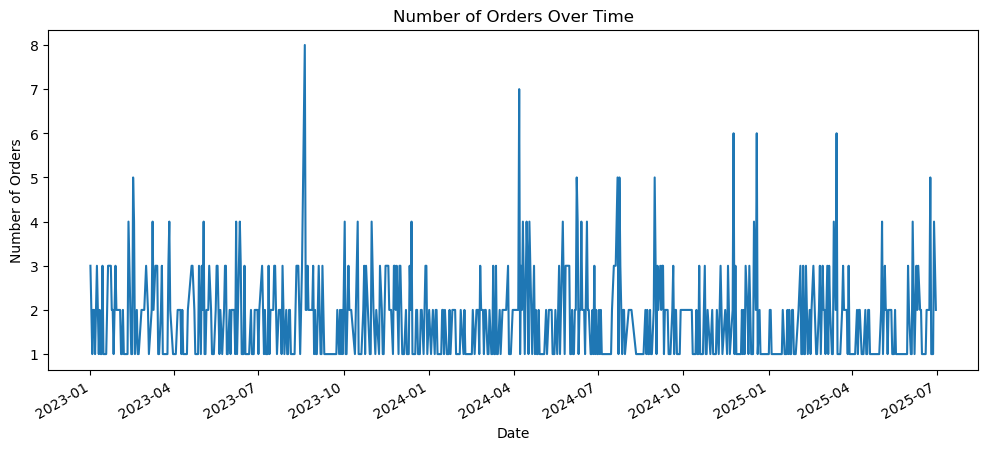

In [21]:
#Trend Chart
import matplotlib.pyplot as plt

orders_by_date.plot(kind="line", figsize=(12, 5))

plt.title("Number of Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

In [22]:
#Total Revenue by date
revenue_by_date = df.groupby("Date")["Total Price"].sum()

In [23]:
revenue_by_date.head()

Date
2023-01-01    2021.11
2023-01-02    1323.55
2023-01-03     897.70
2023-01-04    3629.54
2023-01-05    3642.30
Name: Total Price, dtype: float64

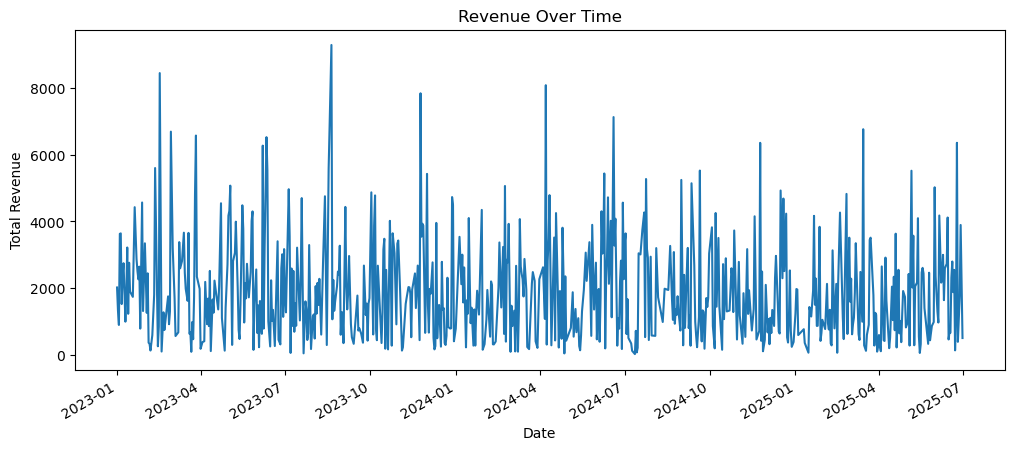

In [24]:
#Revenue Trend chart
revenue_by_date.plot(kind="line", figsize=(12, 5))

plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

In [25]:
#Highest Revenue date
revenue_by_date.idxmax()

Timestamp('2023-08-20 00:00:00')

In [26]:
#Total Revenue by Product
revenue_by_product = df.groupby("Product")["Total Price"].sum().sort_values(ascending=False)

revenue_by_product

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: Total Price, dtype: float64

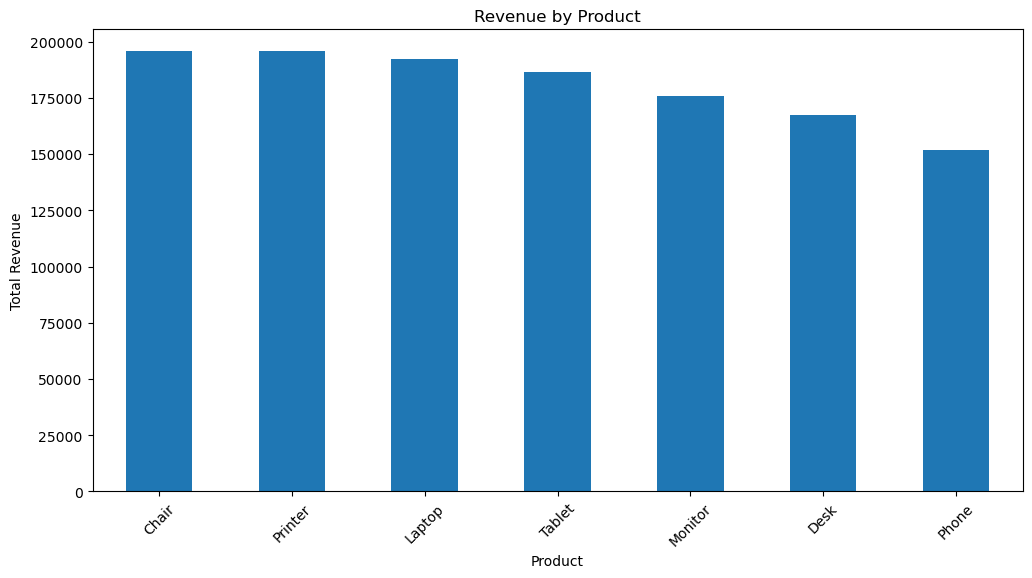

In [27]:
#Total Revenue by product Chart
revenue_by_product.plot(kind="bar", figsize=(12, 6))

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [28]:
#The number of units sold
quantity_by_product = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

quantity_by_product

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

In [29]:
#Count orders by status
order_status = df["Order Status"].value_counts()

order_status

Order Status
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [30]:
# Percentage of each order by status
status_percentage = df["Order Status"].value_counts(normalize=True) * 100

status_percentage

Order Status
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64

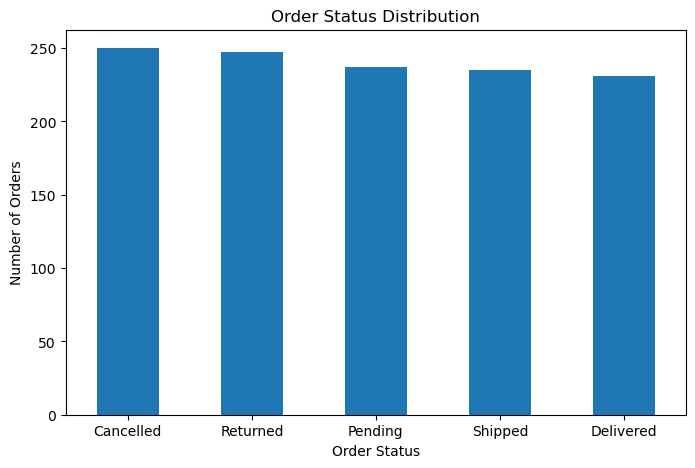

In [31]:
#Orders by status chart
order_status.plot(kind="bar", figsize=(8, 5))

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [32]:
#Count of each payment method
payment_counts = df["Payment Method"].value_counts()

payment_counts

Payment Method
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

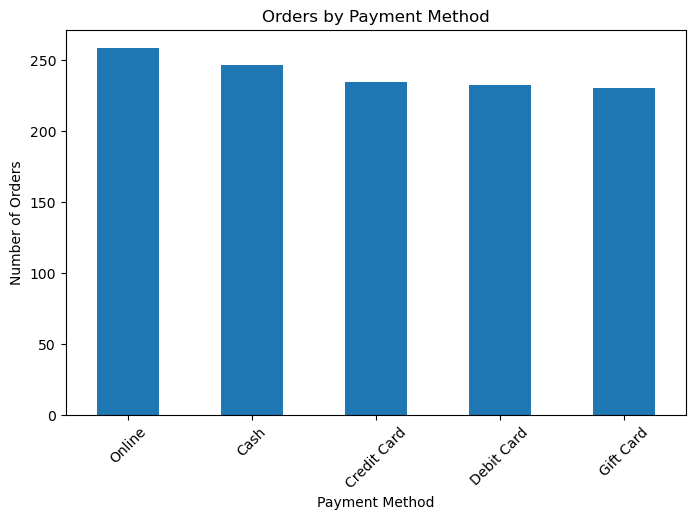

In [33]:
#Payment method chart
payment_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [34]:
#counts of referral source 
referral_counts = df["Referral Source"].value_counts()

referral_counts

Referral Source
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

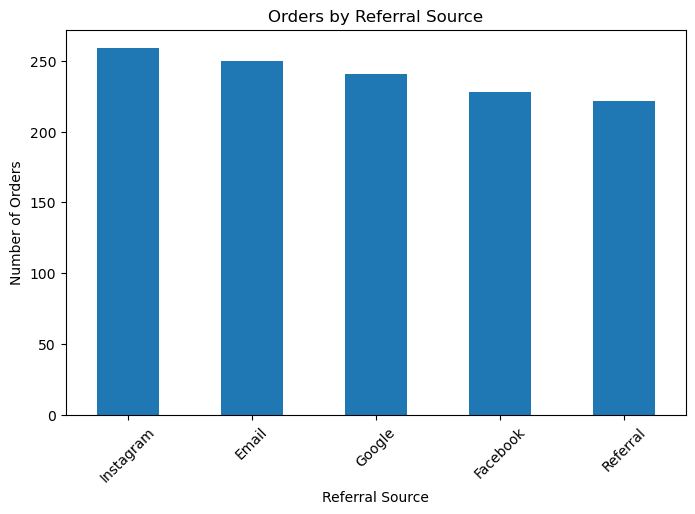

In [35]:
#Referral source chart
referral_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [36]:
#revenue generated by each referral source
revenue_by_referral = (
    df.groupby("Referral Source")["Total Price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_referral

Referral Source
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: Total Price, dtype: float64

In [37]:
#Correlation between Quantity,Unit price, Items in cart and total price.
numeric_columns = [
    "Quantity",
    "Unit Price",
    "Items In Cart",
    "Total Price"
]

df[numeric_columns].corr()

,Quantity,Unit Price,Items In Cart,Total Price
Quantity,1.000000,0.014553,0.650061,0.615251
Unit Price,0.014553,1.000000,0.000602,0.717081
Items In Cart,0.650061,0.000602,1.000000,0.392540
Total Price,0.615251,0.717081,0.392540,1.000000


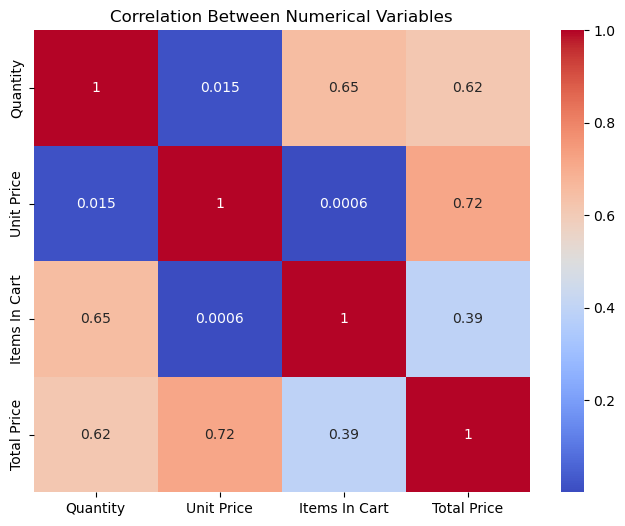

In [38]:
#Correlation heatmap
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

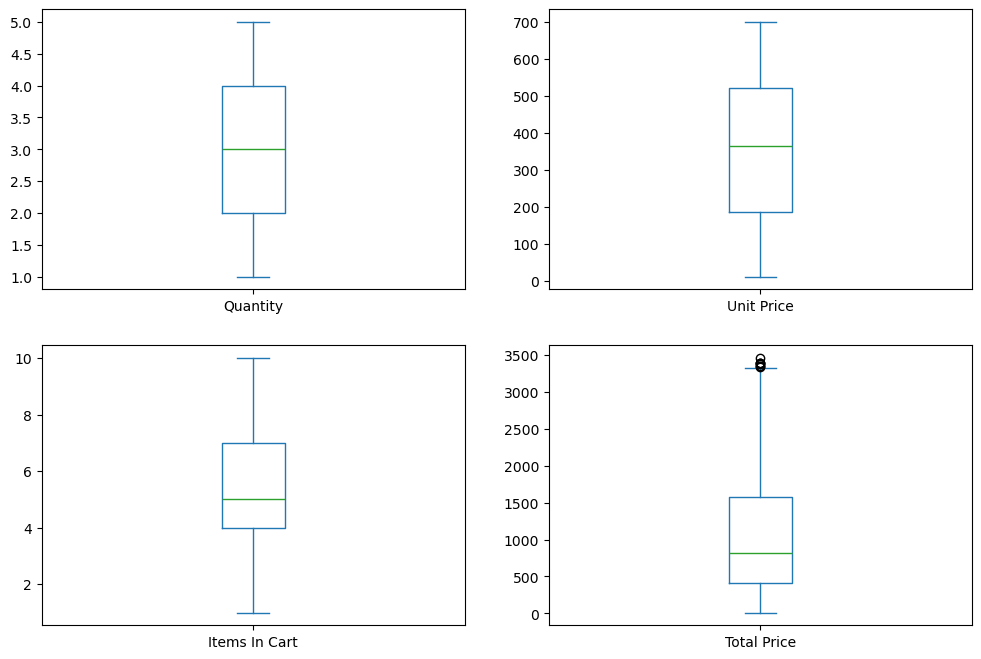

In [39]:
#Outliers
df[numeric_columns].plot(
    kind="box",
    subplots=True,
    layout=(2, 2),
    figsize=(12, 8)
)

plt.show()

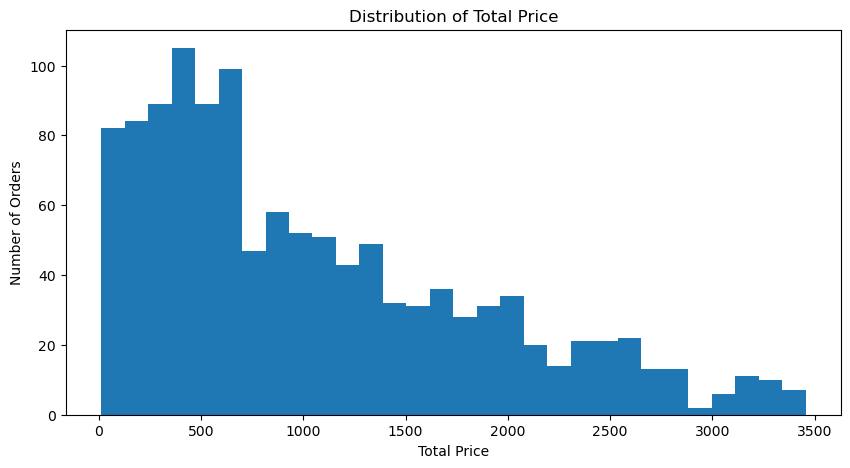

In [40]:
#Distribution of Total Price.
df["Total Price"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")
plt.show()